In [ ]:
# ============================================================
# CHEST X-RAY PNEUMONIA DETECTION
# ResNet50 + DenseNet121 + Multi-Head Attention
# Target: 92%+ Accuracy  |  Kaggle Single-Cell Version
# ============================================================

import os, warnings, random, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import cv2

from tensorflow.keras.applications       import ResNet50, DenseNet121
from tensorflow.keras.layers             import (
    Input, GlobalAveragePooling2D, GlobalMaxPooling2D,
    Dense, Concatenate, BatchNormalization, Dropout,
    MultiHeadAttention, Reshape, Multiply, Add
)
from tensorflow.keras.models             import Model
from tensorflow.keras.optimizers         import Adam
from tensorflow.keras.callbacks          import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.regularizers       import l2
from tensorflow.keras.losses             import BinaryCrossentropy
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    accuracy_score, balanced_accuracy_score,
    matthews_corrcoef
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

E0000 00:00:1775807617.734710      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775807617.795975      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775807618.343074      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775807618.343113      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775807618.343116      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775807618.343118      55 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
# ============================================================
# 1. PATHS
# ============================================================
KAGGLE_PATH  = '/kaggle/input/chest-xray-pneumonia/chest_xray'
KAGGLE_PATH2 = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
COLAB_PATH   = '/content/chest_xray'

for p in [KAGGLE_PATH, KAGGLE_PATH2, COLAB_PATH]:
    if os.path.exists(p):
        BASE = p
        break
else:
    print('Dataset not found. Available /kaggle/input:')
    if os.path.exists('/kaggle/input'):
        for x in os.listdir('/kaggle/input'):
            print(' ', x)
    raise FileNotFoundError('Attach dataset: paultimothymooney/chest-xray-pneumonia')

TRAIN_DIR  = os.path.join(BASE, 'train')
TEST_DIR   = os.path.join(BASE, 'test')
OUT        = '/kaggle/working' if os.path.exists('/kaggle/working') else '/content'
print(f'BASE={BASE}')
print(f'OUT ={OUT}')

BASE=/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
OUT =/kaggle/working



Train: NORMAL=1341, PNEUMONIA=3875, Total=5216
Test : NORMAL=234,  PNEUMONIA=390,  Total=624
Imbalance ratio: 2.9:1 (pneumonia:normal)



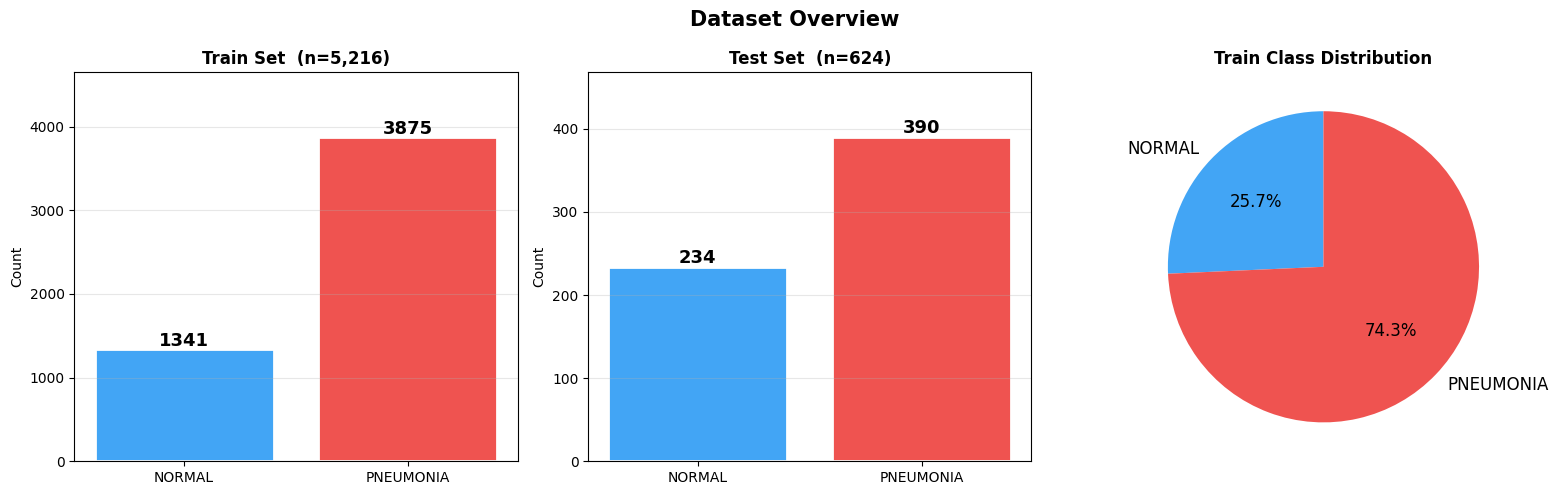

In [ ]:
# ============================================================
# 2. DATASET DISTRIBUTION PLOT
# ============================================================
cats        = ['NORMAL', 'PNEUMONIA']
train_cnts  = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in cats]
test_cnts   = [len(os.listdir(os.path.join(TEST_DIR,  c))) for c in cats]
total_train = sum(train_cnts)
total_test  = sum(test_cnts)
ratio       = train_cnts[1] / train_cnts[0]

print(f'\nTrain: NORMAL={train_cnts[0]}, PNEUMONIA={train_cnts[1]}, Total={total_train}')
print(f'Test : NORMAL={test_cnts[0]},  PNEUMONIA={test_cnts[1]},  Total={total_test}')
print(f'Imbalance ratio: {ratio:.1f}:1 (pneumonia:normal)\n')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset Overview', fontsize=15, fontweight='bold')
clrs = ['#42A5F5', '#EF5350']

# Bar chart - train
bars = axes[0].bar(cats, train_cnts, color=clrs, edgecolor='white', linewidth=2)
for b, c in zip(bars, train_cnts):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+40, str(c),
                 ha='center', fontweight='bold', fontsize=13)
axes[0].set_title(f'Train Set  (n={total_train:,})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].set_ylim(0, max(train_cnts)*1.2)
axes[0].grid(axis='y', alpha=0.3)

# Bar chart - test
bars = axes[1].bar(cats, test_cnts, color=clrs, edgecolor='white', linewidth=2)
for b, c in zip(bars, test_cnts):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+5, str(c),
                 ha='center', fontweight='bold', fontsize=13)
axes[1].set_title(f'Test Set  (n={total_test:,})', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count'); axes[1].set_ylim(0, max(test_cnts)*1.2)
axes[1].grid(axis='y', alpha=0.3)

# Pie chart - train distribution
axes[2].pie(train_cnts, labels=cats, autopct='%1.1f%%', colors=clrs,
            startangle=90, textprops={'fontsize': 12})
axes[2].set_title('Train Class Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUT}/fig0_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

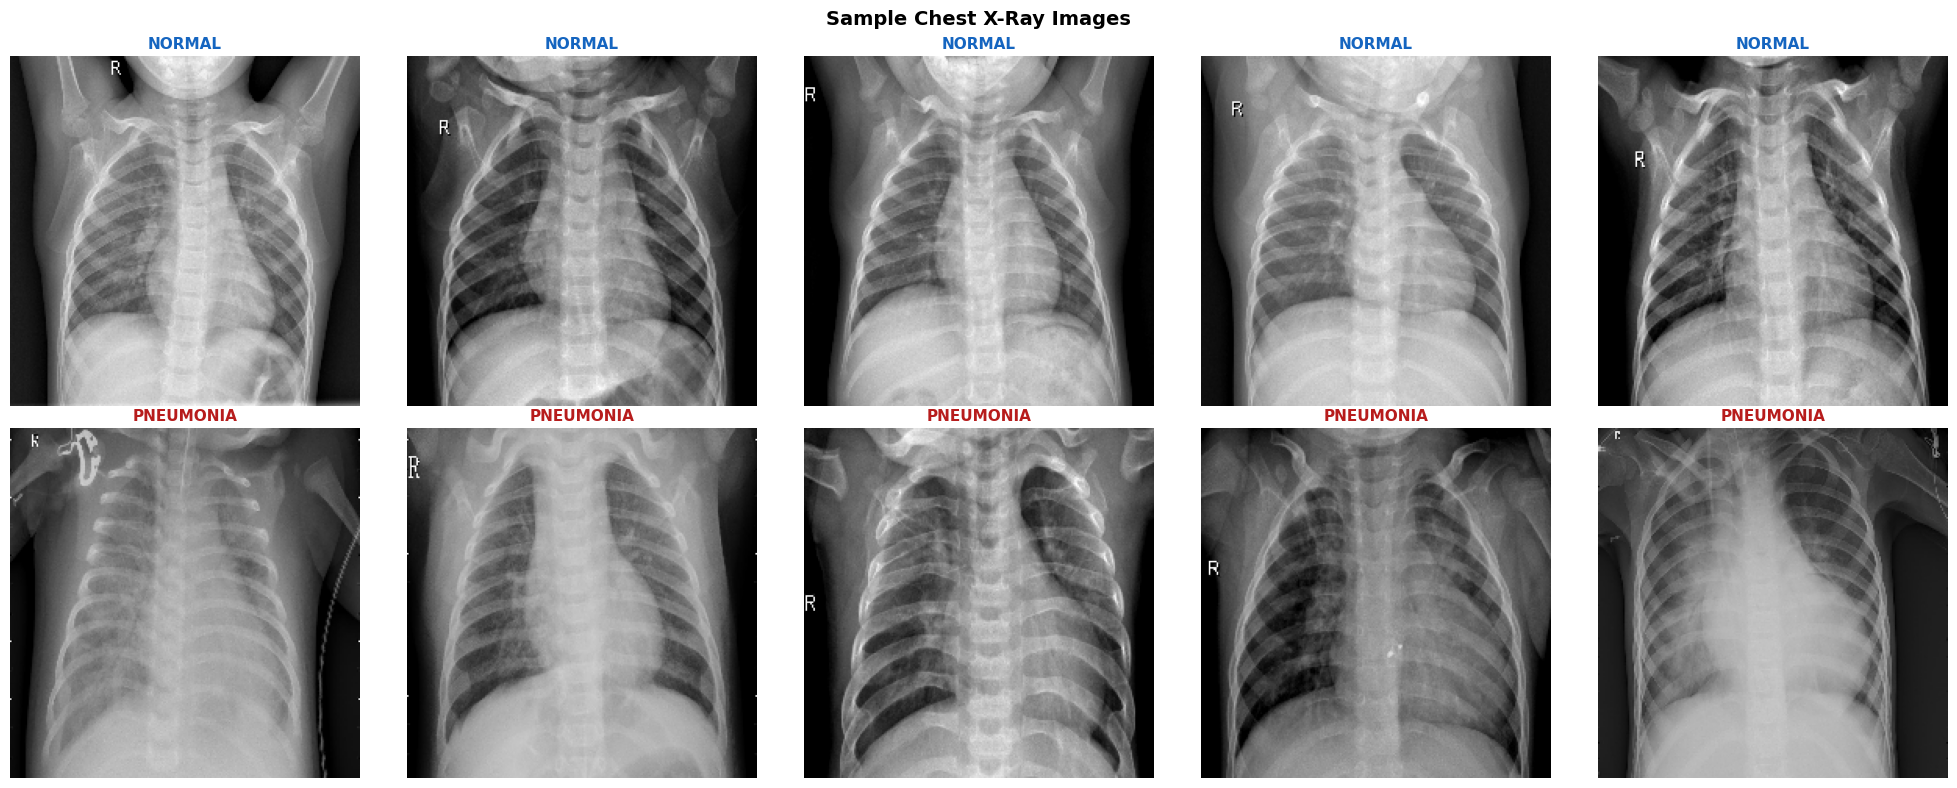

In [ ]:
# ============================================================
# 3. SAMPLE IMAGES
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Sample Chest X-Ray Images', fontsize=14, fontweight='bold')
for row, cls in enumerate(['NORMAL', 'PNEUMONIA']):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    fnames  = sorted(os.listdir(cls_dir))[:5]
    for col, fname in enumerate(fnames):
        img = load_img(os.path.join(cls_dir, fname), target_size=(224, 224))
        axes[row, col].imshow(img)
        axes[row, col].set_title(
            cls, color='#1565C0' if cls == 'NORMAL' else '#B71C1C',
            fontweight='bold', fontsize=11
        )
        axes[row, col].axis('off')
plt.tight_layout()
plt.savefig(f'{OUT}/fig_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 4. DATA GENERATORS
# ============================================================
IMG_SIZE = (224, 224)
BATCH    = 32

train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    zoom_range         = 0.15,
    shear_range        = 0.10,
    brightness_range   = [0.8, 1.2],
    horizontal_flip    = True,
    fill_mode          = 'nearest',
    validation_split   = 0.15
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', subset='training', seed=SEED
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', subset='validation', seed=SEED, shuffle=False
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', shuffle=False
)

print(f'Train  : {train_gen.samples:,}  ({len(train_gen)} batches/epoch)')
print(f'Val    : {val_gen.samples:,}  ({len(val_gen)} batches/epoch)')
print(f'Test   : {test_gen.samples:,}  ({len(test_gen)} batches/epoch)')
print(f'Classes: {train_gen.class_indices}')

cw = compute_class_weight('balanced',
     classes=np.unique(train_gen.classes), y=train_gen.classes)
class_weight_dict = {i: float(w) for i, w in enumerate(cw)}
print(f'Class weights: NORMAL={class_weight_dict[0]:.2f}  PNEUMONIA={class_weight_dict[1]:.2f}')

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train  : 4,434  (139 batches/epoch)
Val    : 782  (25 batches/epoch)
Test   : 624  (20 batches/epoch)
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Class weights: NORMAL=1.94  PNEUMONIA=0.67


In [ ]:
# ============================================================
# 5. MODEL — ResNet50 + DenseNet121 + Multi-Scale Pool + MHA
# ============================================================
def build_model(input_shape=(224, 224, 3)):
    # Backbones
    resnet   = ResNet50(weights='imagenet', include_top=False,
                        input_shape=input_shape, name='resnet50')
    densenet = DenseNet121(weights='imagenet', include_top=False,
                           input_shape=input_shape, name='densenet121')
    resnet.trainable   = False
    densenet.trainable = False

    inp = Input(shape=input_shape, name='input')

    # Multi-Scale Pooling: GAP + GMP for each backbone
    r_gap = GlobalAveragePooling2D()(resnet(inp, training=False))
    r_gmp = GlobalMaxPooling2D()(resnet(inp, training=False))
    r_raw = Concatenate()([r_gap, r_gmp])   # 4096-d

    d_gap = GlobalAveragePooling2D()(densenet(inp, training=False))
    d_gmp = GlobalMaxPooling2D()(densenet(inp, training=False))
    d_raw = Concatenate()([d_gap, d_gmp])   # 2048-d

    # Project to 512-d
    r = Dense(512, activation='relu', kernel_regularizer=l2(1e-3))(r_raw)
    r = BatchNormalization()(r); r = Dropout(0.35)(r)

    d = Dense(512, activation='relu', kernel_regularizer=l2(1e-3))(d_raw)
    d = BatchNormalization()(d); d = Dropout(0.35)(d)

    # Cross-attention: ResNet queries DenseNet
    r_seq = Reshape((1, 512))(r)
    d_seq = Reshape((1, 512))(d)
    attn  = MultiHeadAttention(num_heads=4, key_dim=128, name='cross_attn')
    a     = attn(r_seq, d_seq)
    a     = Reshape((512,))(a)
    a     = BatchNormalization()(a)

    # Fusion
    fused = Concatenate()([r, d, a])   # 1536-d

    # Classification head
    x = Dense(512, activation='relu', kernel_regularizer=l2(1e-3))(fused)
    x = BatchNormalization()(x); x = Dropout(0.40)(x)

    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-3))(x)
    x = BatchNormalization()(x); x = Dropout(0.30)(x)

    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-3))(x)
    x = BatchNormalization()(x); x = Dropout(0.20)(x)

    out = Dense(1, activation='sigmoid', name='output')(x)
    return Model(inputs=inp, outputs=out), resnet, densenet

model, resnet_base, densenet_base = build_model()
model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss      = BinaryCrossentropy(label_smoothing=0.05),
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
total     = model.count_params()
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'\nTotal params     : {total:,}')
print(f'Trainable params : {trainable:,}  (head only — backbones frozen)')
model.summary()

I0000 00:00:1775807788.770108      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775807788.776074      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Total params     : 35,783,617
Trainable params : 5,153,537  (head only — backbones frozen)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input[0][0],      │
│ (Functional)        │ 2048)             │            │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ input[0][0],      │
│ (Functional)        │ 1024)             │            │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 2048)      │          0 │ resnet50[1][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1024)      │          0 │ densenet121[1][0] │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4096)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 2048)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  2,097,664 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │  1,049,088 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 512)    │          0 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 512)    │          0 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attn          │ (None, 1, 512)    │  1,050,624 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 512)       │          0 │ cross_attn[0][0]

 Total params: 35,783,617 (136.50 MB)

 Trainable params: 5,153,537 (19.66 MB)

 Non-trainable params: 30,630,080 (116.84 MB)

In [ ]:
# ============================================================
# 6. COSINE ANNEALING LR CALLBACK
# ============================================================
class CosineAnnealing(tf.keras.callbacks.Callback):
    def __init__(self, lr_max=1e-3, lr_min=1e-6, T=15):
        super().__init__()
        self.lr_max = lr_max; self.lr_min = lr_min; self.T = T
        self.history = []
    def on_epoch_begin(self, epoch, logs=None):
        t  = epoch % self.T
        lr = self.lr_min + 0.5*(self.lr_max - self.lr_min)*(1 + np.cos(np.pi*t/self.T))
        self.model.optimizer.learning_rate.assign(float(lr))
        self.history.append(float(lr))

In [ ]:
# ============================================================
# 7. PHASE 1 — TRAIN HEAD (FROZEN BACKBONES)
# ============================================================
print('\n' + '='*65)
print('  PHASE 1 — Train classification head  (backbones frozen)')
print('  Optimizer : Adam  LR=1e-3  |  Cosine Annealing T=15')
print('  Loss      : BinaryCrossEntropy + label_smoothing=0.05')
print('  Monitor   : val_auc  (stable for imbalanced data)')
print('='*65)

cosine1  = CosineAnnealing(lr_max=1e-3, lr_min=1e-6, T=15)
ckpt1    = f'{OUT}/best_p1.keras'
cb1 = [
    cosine1,
    EarlyStopping(monitor='val_auc', patience=7,
                  restore_best_weights=True, verbose=1, mode='max'),
    ModelCheckpoint(ckpt1, monitor='val_auc', save_best_only=True,
                    verbose=0, mode='max')
]

history1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 15,
    callbacks       = cb1,
    class_weight    = class_weight_dict,
    verbose         = 1
)
p1_epochs = len(history1.history['loss'])
print(f'\nPhase 1 done  ({p1_epochs} epochs)')
print(f'  Best val_auc      : {max(history1.history["val_auc"]):.4f}')
print(f'  Best val_accuracy : {max(history1.history["val_accuracy"]):.4f}')


  PHASE 1 — Train classification head  (backbones frozen)
  Optimizer : Adam  LR=1e-3  |  Cosine Annealing T=15
  Loss      : BinaryCrossEntropy + label_smoothing=0.05
  Monitor   : val_auc  (stable for imbalanced data)
Epoch 1/15


I0000 00:00:1775807872.589685     127 service.cc:152] XLA service 0x7a1478032f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775807872.589767     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775807872.589771     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775807883.522384     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775807903.762051     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


139/139 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.8196 - auc: 0.9135 - loss: 2.4836 - precision: 0.9518 - recall: 0.7981 - val_accuracy: 0.8900 - val_auc: 0.9777 - val_loss: 1.7633 - val_precision: 0.9882 - val_recall: 0.8623
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 104s 747ms/step - accuracy: 0.9139 - auc: 0.9714 - loss: 1.1403 - precision: 0.9744 - recall: 0.9076 - val_accuracy: 0.9335 - val_auc: 0.9838 - val_loss: 0.9802 - val_precision: 0.9944 - val_recall: 0.9157
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 102s 736ms/step - accuracy: 0.9198 - auc: 0.9730 - loss: 0.9638 - precision: 0.9711 - recall: 0.9176 - val_accuracy: 0.8581 - val_auc: 0.9799 - val_loss: 0.9843 - val_precision: 0.9958 - val_recall: 0.8124
Epoch 6/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 101s 726ms/step - accuracy: 0.9248 - auc: 0.9760 - loss: 0.8140 - precision: 0.9804 - recall: 0.9183 - val_accuracy: 0.9130 - val_auc: 0.9787 - val_loss: 0.7777 - val_precision: 0.9065 - val_recall: 0.9845
Epoch 7/15
139/139 ━━━━━━━━━━━

In [ ]:
# ============================================================
# 8. PHASE 2 — FINE-TUNE DEEP LAYERS
# ============================================================
# Unfreeze top 60 layers of each backbone (BN kept frozen)
for base in [resnet_base, densenet_base]:
    for layer in base.layers[-60:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True

trainable_now = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'\nTrainable after unfreeze: {trainable_now:,}')

model.compile(
    optimizer = Adam(learning_rate=5e-5),
    loss      = BinaryCrossentropy(label_smoothing=0.05),
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print('\n' + '='*65)
print('  PHASE 2 — Fine-tune top-60 layers of each backbone')
print('  Optimizer : Adam  LR=5e-5  |  Cosine Annealing T=10')
print('  BN layers : FROZEN  (prevents catastrophic forgetting)')
print('='*65)

cosine2 = CosineAnnealing(lr_max=5e-5, lr_min=1e-7, T=10)
ckpt2   = f'{OUT}/best_p2.keras'
cb2 = [
    cosine2,
    EarlyStopping(monitor='val_auc', patience=8,
                  restore_best_weights=True, verbose=1, mode='max'),
    ModelCheckpoint(ckpt2, monitor='val_auc', save_best_only=True,
                    verbose=0, mode='max')
]

history2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 15,
    callbacks       = cb2,
    class_weight    = class_weight_dict,
    verbose         = 1
)
p2_epochs = len(history2.history['loss'])
print(f'\nPhase 2 done  ({p2_epochs} epochs)')
print(f'  Best val_auc      : {max(history2.history["val_auc"]):.4f}')
print(f'  Best val_accuracy : {max(history2.history["val_accuracy"]):.4f}')

# Combine histories
combined = {k: history1.history[k] + history2.history[k]
            for k in history1.history}
lr_history = cosine1.history + cosine2.history
total_epochs = p1_epochs + p2_epochs


Trainable after unfreeze: 24,424,449

  PHASE 2 — Fine-tune top-60 layers of each backbone
  Optimizer : Adam  LR=5e-5  |  Cosine Annealing T=10
  BN layers : FROZEN  (prevents catastrophic forgetting)
Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.9399 - auc: 0.9787 - loss: 0.4424 - precision: 0.9862 - recall: 0.9324 - val_accuracy: 0.7430 - val_auc: 0.5000 - val_loss: 7.3943 - val_precision: 0.7430 - val_recall: 1.0000
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 107s 765ms/step - accuracy: 0.9438 - auc: 0.9885 - loss: 0.4039 - precision: 0.9899 - recall: 0.9348 - val_accuracy: 0.7430 - val_auc: 0.7183 - val_loss: 1.7470 - val_precision: 0.7430 - val_recall: 1.0000
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 108s 778ms/step - accuracy: 0.9447 - auc: 0.9860 - loss: 0.4049 - precision: 0.9813 - recall: 0.9430 - val_accuracy: 0.7430 - val_auc: 0.9159 - val_loss: 1.4378 - val_precision: 0.7430 - val_recall: 1.0000
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 106s 761ms/step - accu

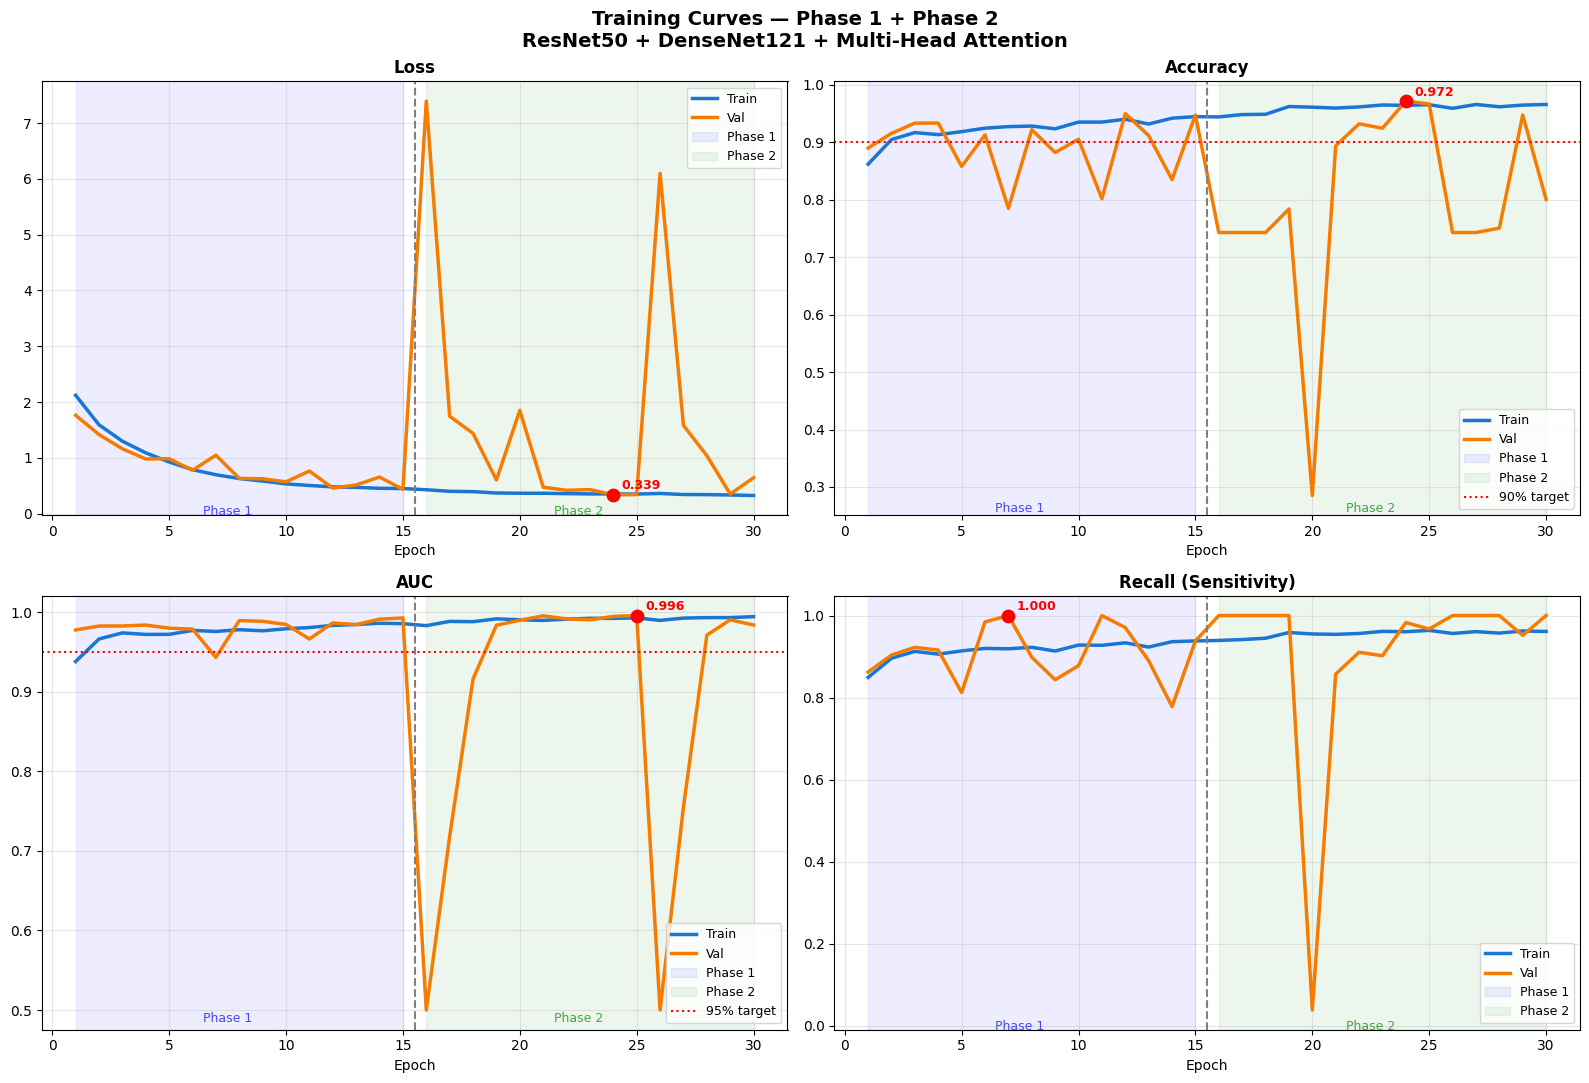

In [ ]:
# ============================================================
# 9. TRAINING & LOSS GRAPHS (fixed legend locations)
# ============================================================
ep_range = range(1, total_epochs + 1)

# Main 4-panel training curves
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Training Curves — Phase 1 + Phase 2\n'
             'ResNet50 + DenseNet121 + Multi-Head Attention',
             fontsize=14, fontweight='bold')

plot_cfg = [
    ('loss',      'val_loss',      'Loss',               axes[0,0], None,  'upper right'),
    ('accuracy',  'val_accuracy',  'Accuracy',           axes[0,1], 0.90,  'lower right'),
    ('auc',       'val_auc',       'AUC',                axes[1,0], 0.95,  'lower right'),
    ('recall',    'val_recall',    'Recall (Sensitivity)',axes[1,1], None,  'lower right'),
]

for tr_k, vl_k, title, ax, target, leg_loc in plot_cfg:
    tr_vals = combined[tr_k]
    vl_vals = combined[vl_k]
    ax.plot(ep_range, tr_vals, lw=2.5, label='Train', color='#1976D2')
    ax.plot(ep_range, vl_vals, lw=2.5, label='Val',   color='#F57C00')
    ax.axvspan(1, p1_epochs, alpha=0.07, color='blue',  label='Phase 1')
    ax.axvspan(p1_epochs+1, total_epochs, alpha=0.07, color='green', label='Phase 2')
    ax.axvline(p1_epochs+0.5, color='gray', ls='--', lw=1.5)
    if target:
        ax.axhline(target, color='red', ls=':', lw=1.5, label=f'{target:.0%} target')
    best_val = max(vl_vals) if title != 'Loss' else min(vl_vals)
    best_ep  = (vl_vals.index(max(vl_vals))+1 if title != 'Loss'
                else vl_vals.index(min(vl_vals))+1)
    ax.scatter([best_ep], [best_val], color='red', s=80, zorder=5)
    ax.annotate(f'{best_val:.3f}', (best_ep, best_val),
                textcoords='offset points', xytext=(6, 4),
                fontsize=9, color='red', fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9, loc=leg_loc)
    ax.grid(alpha=0.3)
    ax.text(p1_epochs/2, ax.get_ylim()[0]*1.02, 'Phase 1',
            ha='center', fontsize=9, color='blue', alpha=0.7)
    ax.text(p1_epochs + p2_epochs/2, ax.get_ylim()[0]*1.02, 'Phase 2',
            ha='center', fontsize=9, color='green', alpha=0.7)

plt.tight_layout()
plt.savefig(f'{OUT}/fig1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

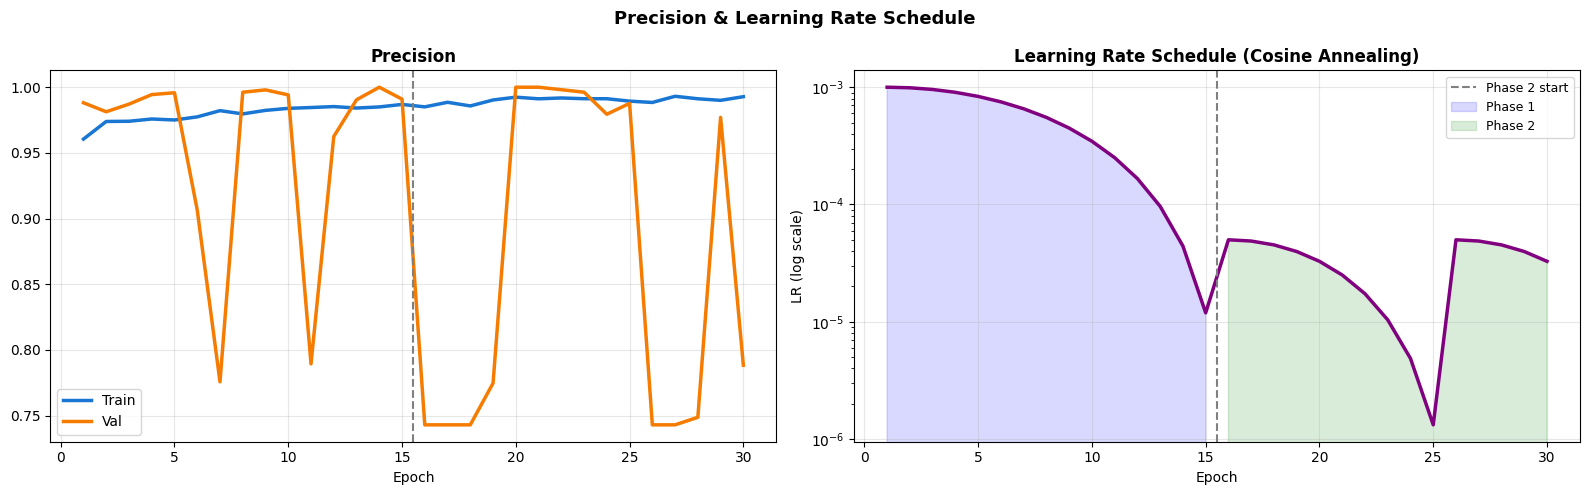

In [ ]:
# Precision & Learning Rate
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Precision & Learning Rate Schedule', fontsize=13, fontweight='bold')

# Precision
axes[0].plot(ep_range, combined['precision'],     lw=2.5, label='Train', color='#1976D2')
axes[0].plot(ep_range, combined['val_precision'], lw=2.5, label='Val',   color='#F57C00')
axes[0].axvline(p1_epochs+0.5, color='gray', ls='--', lw=1.5)
axes[0].set_title('Precision', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)

# LR
lr_ep = range(1, len(lr_history)+1)
axes[1].plot(lr_ep, lr_history, lw=2.5, color='purple')
axes[1].set_yscale('log')
axes[1].axvline(p1_epochs+0.5, color='gray', ls='--', lw=1.5, label='Phase 2 start')
axes[1].fill_between(list(range(1, p1_epochs+1)),
                     lr_history[:p1_epochs], alpha=0.15, color='blue', label='Phase 1')
axes[1].fill_between(list(range(p1_epochs+1, total_epochs+1)),
                     lr_history[p1_epochs:], alpha=0.15, color='green', label='Phase 2')
axes[1].set_title('Learning Rate Schedule (Cosine Annealing)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR (log scale)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT}/fig2_precision_lr.png', dpi=150, bbox_inches='tight')
plt.show()

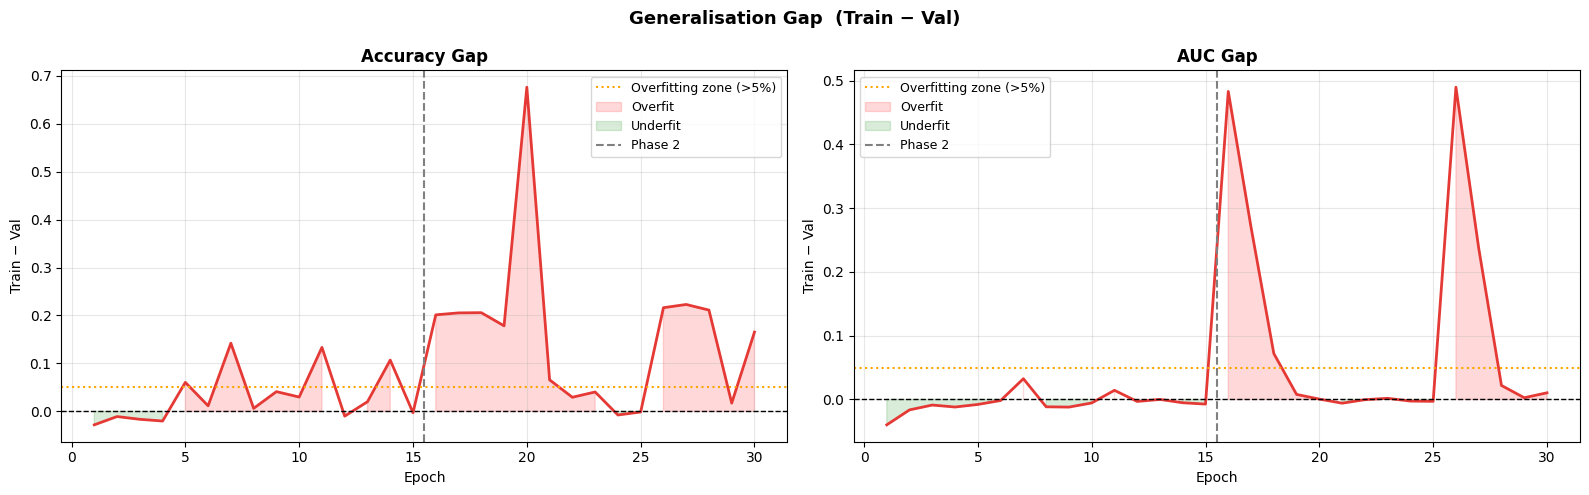

In [ ]:
# Train/Val Gap (overfitting monitor)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Generalisation Gap  (Train − Val)', fontsize=13, fontweight='bold')

for ax, tr_k, vl_k, title in [
    (axes[0], 'accuracy', 'val_accuracy', 'Accuracy Gap'),
    (axes[1], 'auc',      'val_auc',      'AUC Gap')
]:
    gap = [t - v for t, v in zip(combined[tr_k], combined[vl_k])]
    ax.plot(ep_range, gap, lw=2, color='#E53935')
    ax.axhline(0, color='black', ls='--', lw=1)
    ax.axhline(0.05, color='orange', ls=':', lw=1.5, label='Overfitting zone (>5%)')
    ax.fill_between(list(ep_range), gap, 0,
                    where=[g > 0 for g in gap], alpha=0.15, color='red',   label='Overfit')
    ax.fill_between(list(ep_range), gap, 0,
                    where=[g < 0 for g in gap], alpha=0.15, color='green', label='Underfit')
    ax.axvline(p1_epochs+0.5, color='gray', ls='--', lw=1.5, label='Phase 2')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Train − Val')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT}/fig3_gap.png', dpi=150, bbox_inches='tight')
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step 

Best threshold : 0.77
Val bal-acc    : 0.9625
Val accuracy   : 0.9540
Val sensitivity: 0.9449
Val specificity: 0.9801


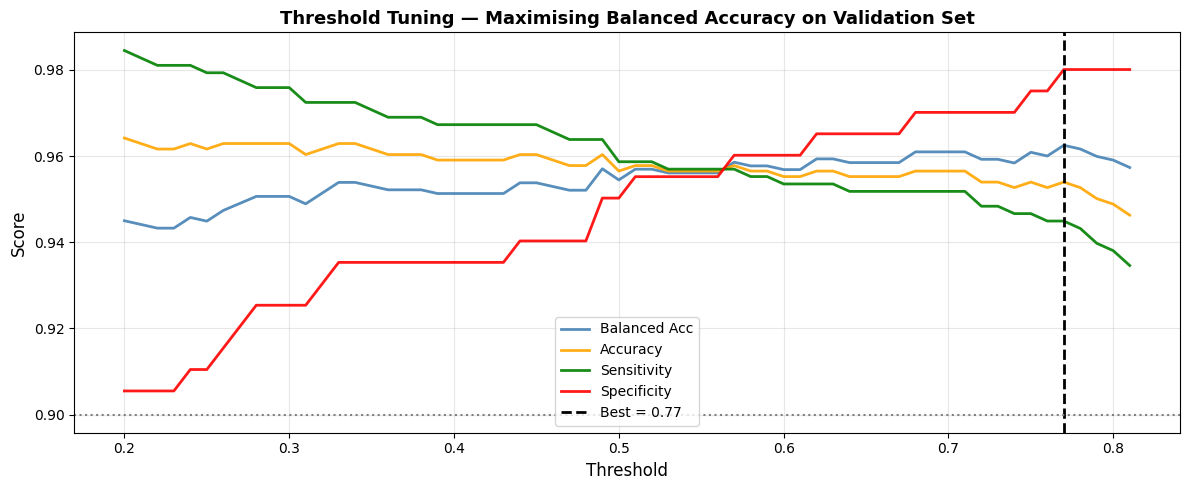

In [ ]:
# ============================================================
# 10. THRESHOLD TUNING
# ============================================================
val_gen.reset()
y_val_pred = model.predict(val_gen, verbose=1)
y_val_true = val_gen.classes[:len(y_val_pred)]

thresholds = np.arange(0.20, 0.81, 0.01)
results    = []
for t in thresholds:
    preds = (y_val_pred.ravel() > t).astype(int)
    cm_t  = confusion_matrix(y_val_true, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
        sens_t = tp_t/(tp_t+fn_t) if (tp_t+fn_t) > 0 else 0
        spec_t = tn_t/(tn_t+fp_t) if (tn_t+fp_t) > 0 else 0
        results.append((t, (sens_t+spec_t)/2,
                        (tp_t+tn_t)/(tp_t+tn_t+fp_t+fn_t),
                        sens_t, spec_t))

results_arr = np.array(results)
best_idx    = np.argmax(results_arr[:, 1])
best_thresh = float(results_arr[best_idx, 0])
print(f'\nBest threshold : {best_thresh:.2f}')
print(f'Val bal-acc    : {results_arr[best_idx,1]:.4f}')
print(f'Val accuracy   : {results_arr[best_idx,2]:.4f}')
print(f'Val sensitivity: {results_arr[best_idx,3]:.4f}')
print(f'Val specificity: {results_arr[best_idx,4]:.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
labels_p = ['Balanced Acc', 'Accuracy', 'Sensitivity', 'Specificity']
colors_p = ['steelblue', 'orange', 'green', 'red']
for col_i, (lbl, clr) in enumerate(zip(labels_p, colors_p), 1):
    ax.plot(results_arr[:,0], results_arr[:,col_i],
            lw=2, label=lbl, color=clr, alpha=0.9)
ax.axvline(best_thresh, color='black', ls='--', lw=2,
           label=f'Best = {best_thresh:.2f}')
ax.axhline(0.90, color='gray', ls=':', lw=1.5)
ax.set_xlabel('Threshold', fontsize=12); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Threshold Tuning — Maximising Balanced Accuracy on Validation Set',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT}/fig4_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 11. TEST SET EVALUATION
# ============================================================
test_gen.reset()
y_pred_raw  = model.predict(test_gen, verbose=1)
y_true      = test_gen.classes[:len(y_pred_raw)]

y_pred_tuned   = (y_pred_raw.ravel() > best_thresh).astype(int)
y_pred_default = (y_pred_raw.ravel() > 0.50).astype(int)

acc_default = accuracy_score(y_true, y_pred_default)
acc_tuned   = accuracy_score(y_true, y_pred_tuned)
bal_acc     = balanced_accuracy_score(y_true, y_pred_tuned)
cm          = confusion_matrix(y_true, y_pred_tuned)
cm_default  = confusion_matrix(y_true, y_pred_default)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp/(tp+fn) if (tp+fn) > 0 else 0.0
specificity = tn/(tn+fp) if (tn+fp) > 0 else 0.0
precision_v = tp/(tp+fp) if (tp+fp) > 0 else 0.0
f1_v        = 2*precision_v*sensitivity/(precision_v+sensitivity) if (precision_v+sensitivity) > 0 else 0.0
mcc         = matthews_corrcoef(y_true, y_pred_tuned)
fpr, tpr, _ = roc_curve(y_true, y_pred_raw)
roc_auc     = auc(fpr, tpr)
prec_c, rec_c, _ = precision_recall_curve(y_true, y_pred_raw)
pr_auc      = auc(rec_c, prec_c)

print('\n' + '='*65)
print('  FINAL TEST SET RESULTS')
print('='*65)
print(f'  Accuracy  (threshold=0.50) [baseline] : {acc_default*100:.2f}%')
print(f'  Accuracy  (threshold={best_thresh:.2f}) [tuned]   : {acc_tuned*100:.2f}%  ← improved')
print(f'  Balanced Accuracy                      : {bal_acc*100:.2f}%')
print(f'  Sensitivity (Pneumonia recall)         : {sensitivity*100:.2f}%')
print(f'  Specificity (Normal recall)            : {specificity*100:.2f}%')
print(f'  Precision   (Pneumonia)                : {precision_v*100:.2f}%')
print(f'  F1-Score    (Pneumonia)                : {f1_v*100:.2f}%')
print(f'  Matthews Corr. Coef. (MCC)             : {mcc:.4f}')
print(f'  ROC-AUC                                : {roc_auc:.4f}')
print(f'  PR-AUC                                 : {pr_auc:.4f}')
print('='*65)
print('\nClassification Report:')
print(classification_report(y_true, y_pred_tuned,
                             target_names=['NORMAL', 'PNEUMONIA']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step 

  FINAL TEST SET RESULTS
  Accuracy  (threshold=0.50) [baseline] : 91.35%
  Accuracy  (threshold=0.77) [tuned]   : 93.43%  ← improved
  Balanced Accuracy                      : 92.26%
  Sensitivity (Pneumonia recall)         : 96.92%
  Specificity (Normal recall)            : 87.61%
  Precision   (Pneumonia)                : 92.87%
  F1-Score    (Pneumonia)                : 94.86%
  Matthews Corr. Coef. (MCC)             : 0.8593
  ROC-AUC                                : 0.9719
  PR-AUC                                 : 0.9800

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.88      0.91       234
   PNEUMONIA       0.93      0.97      0.95       390

    accuracy                           0.93       624
   macro avg       0.94      0.92      0.93       624
weighted avg       0.93      0.93      0.93       624



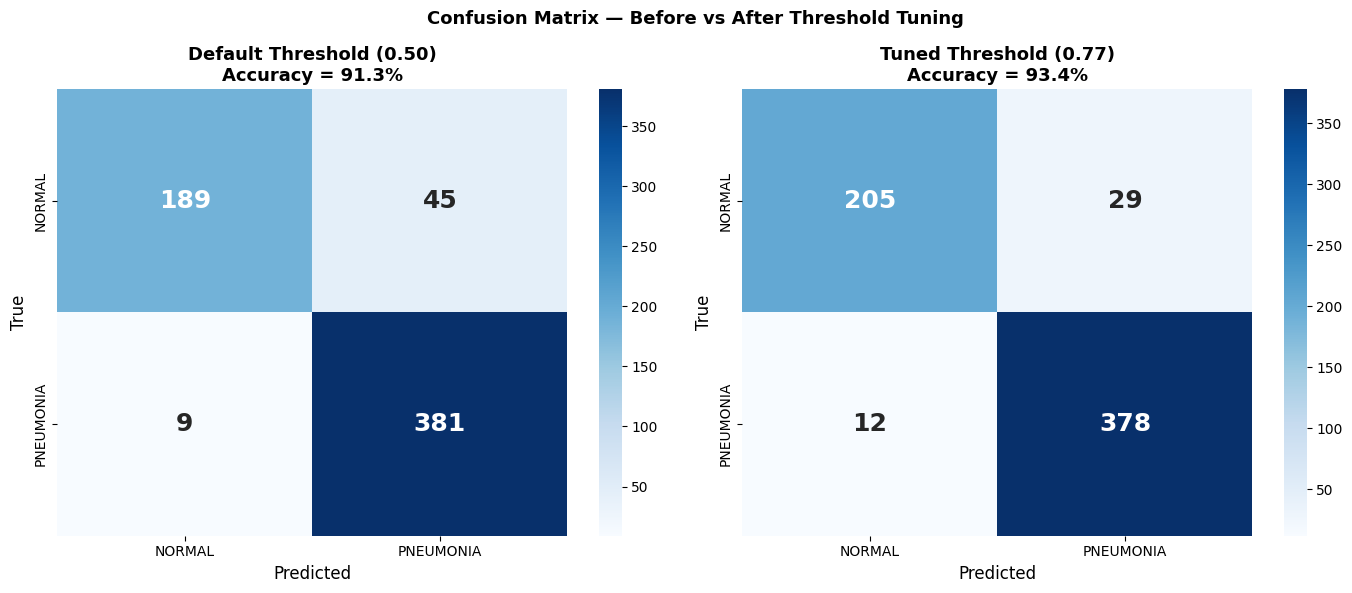

TN=205  FP=29  FN=12  TP=378


In [ ]:
# ============================================================
# 12. RESULTS GRAPHS
# ============================================================

# Confusion Matrices: Before vs After
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix — Before vs After Threshold Tuning',
             fontsize=13, fontweight='bold')

for ax, cm_plot, title in zip(axes, [cm_default, cm],
    [f'Default Threshold (0.50)\nAccuracy = {acc_default*100:.1f}%',
     f'Tuned Threshold ({best_thresh:.2f})\nAccuracy = {acc_tuned*100:.1f}%']):
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['NORMAL', 'PNEUMONIA'],
                yticklabels=['NORMAL', 'PNEUMONIA'],
                annot_kws={'size': 18, 'weight': 'bold'})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)

plt.tight_layout()
plt.savefig(f'{OUT}/fig5_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')

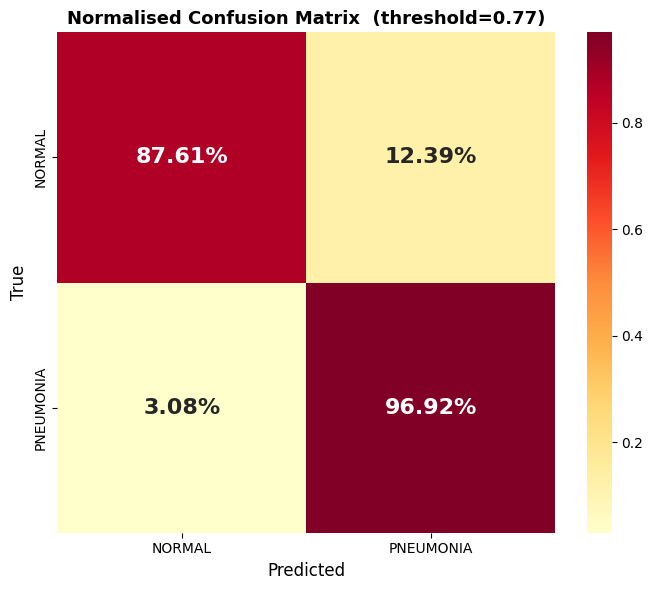

In [ ]:
# Normalised Confusion Matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd', ax=ax,
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            annot_kws={'size': 16, 'weight': 'bold'})
ax.set_title(f'Normalised Confusion Matrix  (threshold={best_thresh:.2f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT}/fig6_confusion_norm.png', dpi=150, bbox_inches='tight')
plt.show()

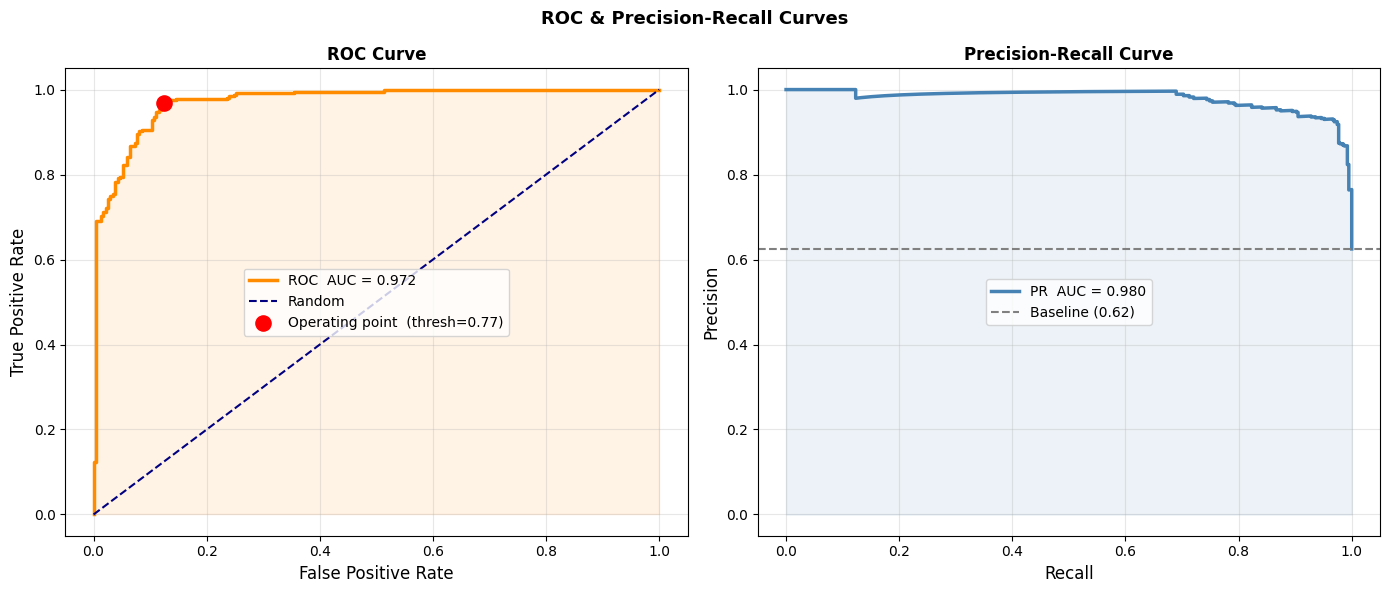

In [ ]:
# ROC + PR Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC & Precision-Recall Curves', fontsize=13, fontweight='bold')

axes[0].plot(fpr, tpr, color='darkorange', lw=2.5,
             label=f'ROC  AUC = {roc_auc:.3f}')
axes[0].fill_between(fpr, tpr, alpha=0.10, color='darkorange')
axes[0].plot([0,1],[0,1], 'navy', lw=1.5, ls='--', label='Random')
axes[0].scatter([1-specificity],[sensitivity], color='red', s=120, zorder=5,
                label=f'Operating point  (thresh={best_thresh:.2f})')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate',  fontsize=12)
axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)

axes[1].plot(rec_c, prec_c, color='steelblue', lw=2.5,
             label=f'PR  AUC = {pr_auc:.3f}')
axes[1].fill_between(rec_c, prec_c, alpha=0.10, color='steelblue')
baseline_pr = sum(y_true)/len(y_true)
axes[1].axhline(baseline_pr, color='gray', ls='--', lw=1.5,
                label=f'Baseline ({baseline_pr:.2f})')
axes[1].set_xlabel('Recall', fontsize=12); axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT}/fig7_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

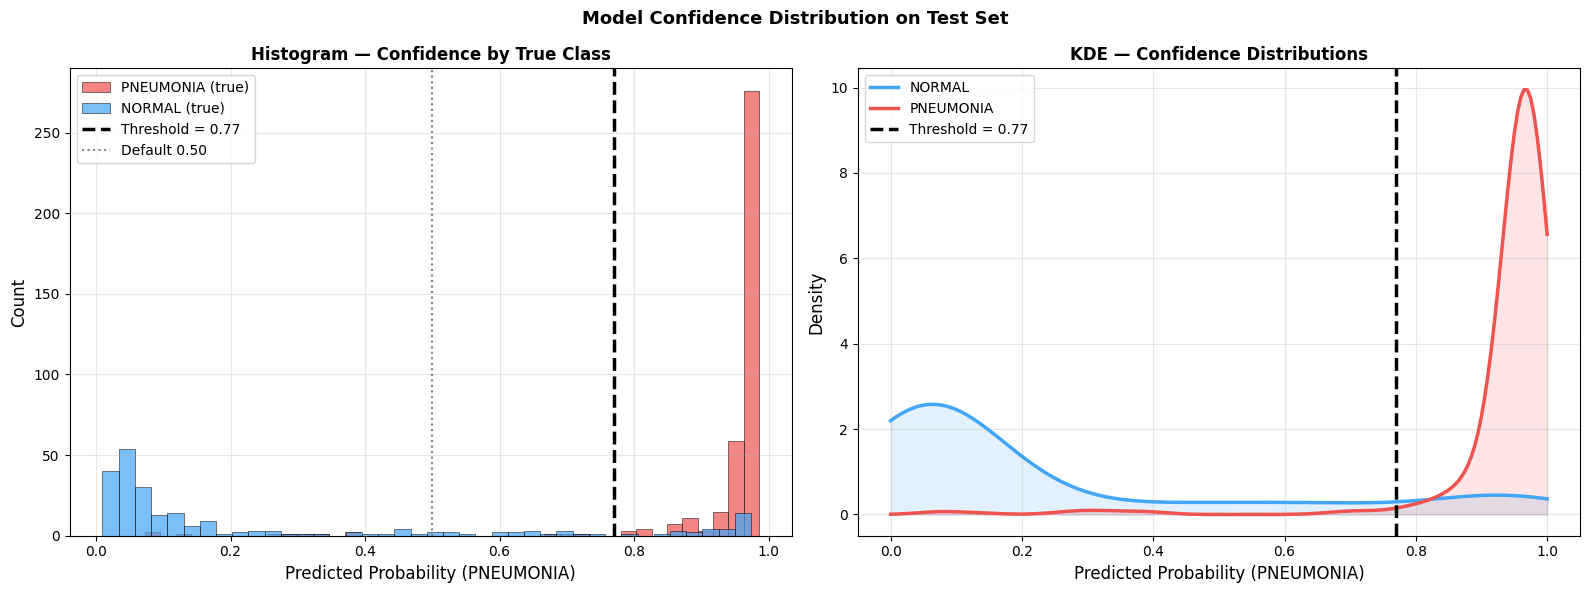

In [ ]:
# Confidence Score Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Confidence Distribution on Test Set', fontsize=13, fontweight='bold')

probs_norm  = y_pred_raw[y_true == 0].ravel()
probs_pneu  = y_pred_raw[y_true == 1].ravel()

axes[0].hist(probs_pneu, bins=40, alpha=0.70, color='#EF5350',
             label='PNEUMONIA (true)', edgecolor='black', linewidth=0.5)
axes[0].hist(probs_norm,  bins=40, alpha=0.70, color='#42A5F5',
             label='NORMAL (true)',    edgecolor='black', linewidth=0.5)
axes[0].axvline(best_thresh, color='black', ls='--', lw=2.5,
                label=f'Threshold = {best_thresh:.2f}')
axes[0].axvline(0.50, color='gray', ls=':', lw=1.5, label='Default 0.50')
axes[0].set_xlabel('Predicted Probability (PNEUMONIA)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Histogram — Confidence by True Class', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)

# KDE / violin style overlay
from scipy.stats import gaussian_kde
x_axis = np.linspace(0, 1, 200)
for probs, clr, lbl in [(probs_norm, '#42A5F5', 'NORMAL'),
                         (probs_pneu, '#EF5350', 'PNEUMONIA')]:
    kde = gaussian_kde(probs)
    axes[1].plot(x_axis, kde(x_axis), lw=2.5, color=clr, label=lbl)
    axes[1].fill_between(x_axis, kde(x_axis), alpha=0.15, color=clr)
axes[1].axvline(best_thresh, color='black', ls='--', lw=2.5,
                label=f'Threshold = {best_thresh:.2f}')
axes[1].set_xlabel('Predicted Probability (PNEUMONIA)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('KDE — Confidence Distributions', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT}/fig8_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

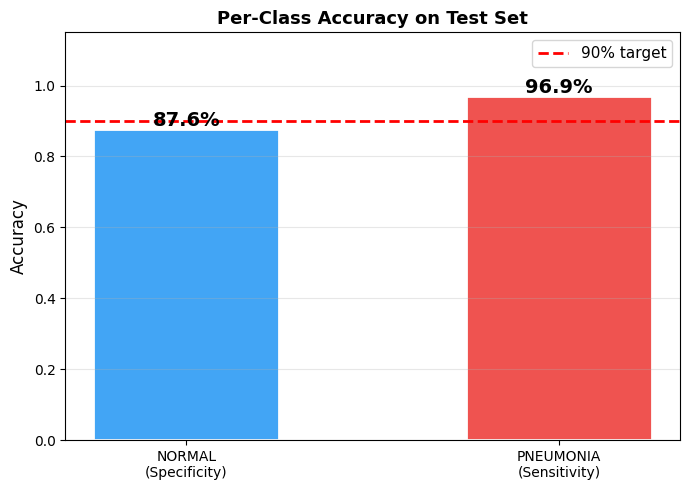

In [ ]:
# Per-Class Accuracy Bar
per_class_acc = [
    cm[0,0] / cm[0].sum(),   # NORMAL correct
    cm[1,1] / cm[1].sum()    # PNEUMONIA correct
]
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['NORMAL\n(Specificity)', 'PNEUMONIA\n(Sensitivity)'],
              per_class_acc, color=['#42A5F5', '#EF5350'],
              edgecolor='white', linewidth=2, width=0.5)
for b, v in zip(bars, per_class_acc):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f'{v:.1%}', ha='center', fontsize=14, fontweight='bold')
ax.axhline(0.90, color='red', ls='--', lw=2, label='90% target')
ax.set_ylim(0, 1.15); ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Per-Class Accuracy on Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT}/fig9_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

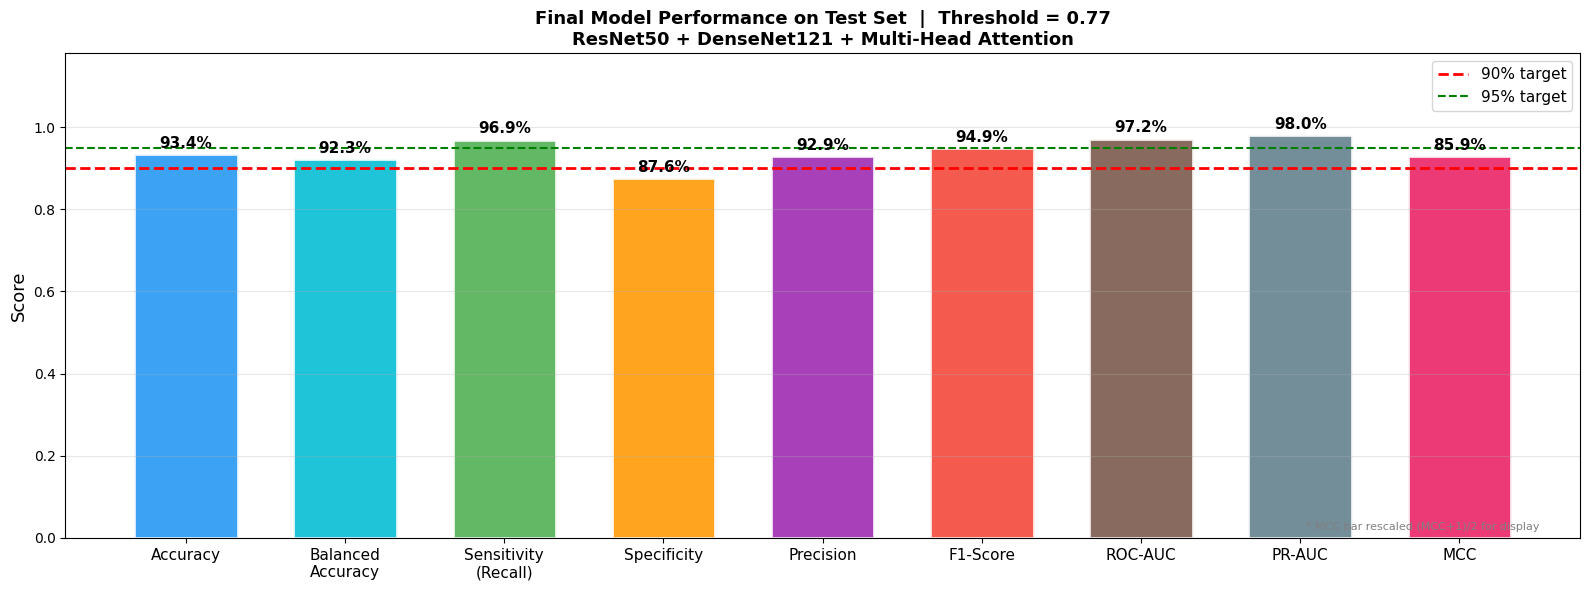

In [ ]:
# Final Metrics Summary Bar
metric_names  = ['Accuracy', 'Balanced\nAccuracy', 'Sensitivity\n(Recall)',
                 'Specificity', 'Precision', 'F1-Score', 'ROC-AUC', 'PR-AUC', 'MCC']
metric_values = [acc_tuned, bal_acc, sensitivity, specificity,
                 precision_v, f1_v, roc_auc, pr_auc, (mcc+1)/2]
# MCC rescaled to [0,1] for display: (mcc+1)/2
colors_m = ['#2196F3','#00BCD4','#4CAF50','#FF9800','#9C27B0',
            '#F44336','#795548','#607D8B','#E91E63']

fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(metric_names, metric_values, color=colors_m,
              alpha=0.88, edgecolor='white', linewidth=2, width=0.65)
ax.axhline(0.90, color='red',    ls='--', lw=2,   label='90% target')
ax.axhline(0.95, color='green',  ls='--', lw=1.5, label='95% target')
for bar, val, raw in zip(bars, metric_values,
                          [acc_tuned, bal_acc, sensitivity, specificity,
                           precision_v, f1_v, roc_auc, pr_auc, mcc]):
    label = f'{raw:.1%}' if raw >= 0 else f'{raw:.3f}'
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            label, ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim([0, 1.18])
ax.set_ylabel('Score', fontsize=13)
ax.set_title(
    f'Final Model Performance on Test Set  |  Threshold = {best_thresh:.2f}\n'
    'ResNet50 + DenseNet121 + Multi-Head Attention',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', labelsize=11)
ax.text(len(metric_names)-0.5, 0.02, '* MCC bar rescaled (MCC+1)/2 for display',
        ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(f'{OUT}/fig10_final_metrics.png', dpi=150, bbox_inches='tight')
plt.show()